# NB6 — Final Evaluation & Benchmarking

**Prerequisites:** NB1 through NB5 must have been run (all 4 models on Drive).

**Steps:**
1. Load all 4 trained models from Google Drive (Keras 3.x-safe RGB CNN loading)
2. Restore NTHU-DDD test data and feature CSV
3. Side-by-side confusion matrices (real predictions where data is available)
4. ROC curves per class (Alert / Drowsy or Alert / Slightly Drowsy / Drowsy)
5. Latency benchmark (100 inference runs each)
6. Attention weight dynamics — day-to-night simulation
7. Final summary table

---

In [1]:
# Install packages (run once per Colab session)
!pip install -q kagglehub mediapipe opencv-python-headless \
    pygame imbalanced-learn tqdm seaborn "protobuf>=5.26.1,<6.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00


In [2]:
# Common imports – run this cell first
import os, sys, cv2, random, time, shutil, urllib.request, h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score)

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU:', gpus[0].name)
else:
    print('NO GPU found - go to Runtime > Change runtime type > T4 GPU')
print('TF:', tf.__version__, '  MP:', mp.__version__)

NO GPU found - go to Runtime > Change runtime type > T4 GPU
TF: 2.19.0   MP: 0.10.32


In [3]:
# Mount Google Drive and configure all paths
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# ── Auto-detect DRIVE_ROOT ───────────────────────────────────────────────────
def find_drive_root():
    candidates = [
        '/content/drive/MyDrive/drowsiness',
        '/content/drive/MyDrive/Drowsiness',
    ]
    shared = '/content/drive/Shareddrives'
    if os.path.isdir(shared):
        for entry in os.listdir(shared):
            candidates.append(os.path.join(shared, entry, 'drowsiness'))
    mydrive = '/content/drive/MyDrive'
    if os.path.isdir(mydrive):
        for entry in os.listdir(mydrive):
            if 'drowsiness' in entry.lower():
                candidates.insert(0, os.path.join(mydrive, entry))
    for c in candidates:
        if os.path.isdir(c):
            print(f'Found Drive root: {c}')
            return c
    path = '/content/drive/MyDrive/drowsiness'
    os.makedirs(path, exist_ok=True)
    print(f'Created Drive root: {path}')
    return path

DRIVE_ROOT    = find_drive_root()
MODEL_DIR     = DRIVE_ROOT + '/models'
DATASET_DIR   = DRIVE_ROOT + '/datasets'
LOCAL_DS_ROOT = '/content/datasets'

for d in [MODEL_DIR, DATASET_DIR, LOCAL_DS_ROOT]:
    os.makedirs(d, exist_ok=True)

nthu_path     = os.path.join(LOCAL_DS_ROOT, 'nthu_ddd')
mrl_path      = os.path.join(LOCAL_DS_ROOT, 'mrl_eye')
combined_path = os.path.join(LOCAL_DS_ROOT, 'combined')

# Model paths — prefer .keras (Keras 3.x native), fall back to .h5
RGB_MODEL_KERAS   = os.path.join(MODEL_DIR, 'rgb_cnn.keras')
RGB_MODEL_H5      = os.path.join(MODEL_DIR, 'rgb_cnn.h5')
IR_MODEL_PATH     = os.path.join(MODEL_DIR, 'ir_cnn.h5')
LSTM_MODEL_PATH   = os.path.join(MODEL_DIR, 'lstm.h5')
FUSION_MODEL_PATH = os.path.join(MODEL_DIR, 'fusion.h5')

CSV_PATH          = '/content/nthu_features.csv'
CSV_DRIVE_PATH    = os.path.join(MODEL_DIR, 'nthu_features.csv')

FACE_LANDMARKER_LOCAL = '/content/face_landmarker.task'
FACE_LANDMARKER_DRIVE = os.path.join(MODEL_DIR, 'face_landmarker.task')

EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
print('Paths configured.')
print('  Model dir  :', MODEL_DIR)
print('  Dataset dir:', LOCAL_DS_ROOT)
print('  RGB .keras :', os.path.exists(RGB_MODEL_KERAS), '|', RGB_MODEL_KERAS)
print('  RGB .h5    :', os.path.exists(RGB_MODEL_H5))
print('  IR model   :', os.path.exists(IR_MODEL_PATH))
print('  LSTM model :', os.path.exists(LSTM_MODEL_PATH))
print('  Fusion     :', os.path.exists(FUSION_MODEL_PATH))

Mounted at /content/drive
Found Drive root: /content/drive/MyDrive/drowsiness
Paths configured.
  Model dir  : /content/drive/MyDrive/drowsiness/models
  Dataset dir: /content/datasets
  RGB .keras : True | /content/drive/MyDrive/drowsiness/models/rgb_cnn.keras
  RGB .h5    : True
  IR model   : True
  LSTM model : True
  Fusion     : True


In [4]:
# ── Keras 3.x-safe model loader ──────────────────────────────────────────────

def _build_rgb_base(num_classes=2):
    """Rebuild MobileNetV3Small-based RGB CNN architecture."""
    base = MobileNetV3Small(
        input_shape=(224, 224, 3), include_top=False,
        weights=None, include_preprocessing=False)
    base.trainable = False
    inp  = keras.Input(shape=(224, 224, 3), name='rgb_input')
    x    = tf.keras.applications.mobilenet_v3.preprocess_input(inp)
    x    = base(x, training=False)
    x    = layers.GlobalAveragePooling2D()(x)
    x    = layers.Dense(256, activation='relu')(x)
    x    = layers.Dropout(0.3)(x)
    feat = layers.Dense(128, activation='relu', name='rgb_features')(x)
    out  = layers.Dense(num_classes, activation='softmax', name='rgb_output')(feat)
    m    = keras.Model(inp, out, name='rgb_cnn')
    m.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

def _load_weights_h5py(h5_path, model):
    """Load weights directly via h5py, bypassing JSON config."""
    loaded = 0
    with h5py.File(h5_path, 'r') as f:
        root = f.get('model_weights', f)
        def _try_load(layer):
            nonlocal loaded
            name = layer.name
            if name in root:
                grp = root[name]
                ws  = [grp[k][()] for k in sorted(grp.keys())]
                if ws and len(ws) == len(layer.weights):
                    try:
                        layer.set_weights(ws)
                        loaded += 1
                    except Exception:
                        pass
        for lyr in model.layers:
            _try_load(lyr)
            for sub in getattr(lyr, 'layers', []):
                _try_load(sub)
    return loaded

def load_rgb_model():
    """Load RGB CNN with Keras 3.x-safe strategies."""
    # Strategy 1: native .keras format
    if os.path.exists(RGB_MODEL_KERAS):
        print('RGB CNN: loading native .keras ...')
        m = keras.models.load_model(RGB_MODEL_KERAS)
        print('RGB CNN loaded via .keras')
        return m

    if not os.path.exists(RGB_MODEL_H5):
        raise FileNotFoundError(
            'rgb_cnn.h5 not found on Drive — re-run NB4.')

    # Strategy 2: load_weights(by_name=True) — skips JSON config deserialization
    print('RGB CNN: trying load_weights(by_name=True) ...')
    try:
        m = _build_rgb_base(num_classes=2)
        m.load_weights(RGB_MODEL_H5, by_name=True, skip_mismatch=True)
        kernel = m.get_layer('rgb_features').get_weights()[0]
        if np.all(kernel == 0):
            raise RuntimeError('weights appear to be all zeros')
        m.save(RGB_MODEL_KERAS)
        print('RGB CNN loaded via load_weights → cached as .keras')
        return m
    except Exception as e:
        print(f'  Strategy 2 failed: {e}')

    # Strategy 3: h5py direct weight reading
    print('RGB CNN: trying h5py direct read ...')
    try:
        m = _build_rgb_base(num_classes=2)
        n_loaded = _load_weights_h5py(RGB_MODEL_H5, m)
        if n_loaded < 3:
            raise RuntimeError(f'Only {n_loaded} layers loaded')
        m.save(RGB_MODEL_KERAS)
        print(f'RGB CNN loaded via h5py ({n_loaded} layers) → cached as .keras')
        return m
    except Exception as e:
        print(f'  Strategy 3 failed: {e}')

    raise RuntimeError(
        'All RGB loading strategies failed.\n'
        '  → Re-run NB4 (which saves rgb_cnn.keras natively).')

# ── Load all 4 models ─────────────────────────────────────────────────────────
print('Loading models from Drive ...')
ir_model     = keras.models.load_model(IR_MODEL_PATH)
rgb_model    = load_rgb_model()
lstm_model   = keras.models.load_model(LSTM_MODEL_PATH)
fusion_model = keras.models.load_model(FUSION_MODEL_PATH)
print('\nAll 4 models loaded.')

# ── Auto-detect class counts from model output shapes ─────────────────────────
N_IR_CLASSES   = ir_model.output_shape[-1]
N_RGB_CLASSES  = rgb_model.output_shape[-1]
N_LSTM_CLASSES = lstm_model.output_shape[-1]
N_FUS_CLASSES  = fusion_model.output_shape[-1]

ALL_CLASS_NAMES = {0: 'Alert', 1: 'Slightly Drowsy', 2: 'Drowsy'}

def get_class_names(n):
    if n == 2:
        return ['Alert', 'Drowsy']
    return [ALL_CLASS_NAMES.get(i, f'Class {i}') for i in range(n)]

IR_CLASS_NAMES   = get_class_names(N_IR_CLASSES)
RGB_CLASS_NAMES  = get_class_names(N_RGB_CLASSES)
LSTM_CLASS_NAMES = get_class_names(N_LSTM_CLASSES)
FUS_CLASS_NAMES  = get_class_names(N_FUS_CLASSES)

print(f'\nClass counts → IR:{N_IR_CLASSES}  RGB:{N_RGB_CLASSES}  '
      f'LSTM:{N_LSTM_CLASSES}  Fusion:{N_FUS_CLASSES}')
for name, m in [('IR CNN', ir_model), ('RGB CNN', rgb_model),
                ('LSTM', lstm_model), ('Fusion', fusion_model)]:
    print(f'  {name:10s}: {m.count_params():,} params')

Loading models from Drive ...


RGB CNN: loading native .keras ...
RGB CNN loaded via .keras



All 4 models loaded.

Class counts → IR:1  RGB:2  LSTM:2  Fusion:2
  IR CNN    : 110,209 params
  RGB CNN   : 1,088,370 params
  LSTM      : 122,306 params
  Fusion    : 86,661 params


In [5]:
# Restore feature CSV and datasets, then build test sets
import tarfile as _tarfile

# ── Restore nthu_features.csv ────────────────────────────────────────────────
if not os.path.exists(CSV_PATH):
    if os.path.exists(CSV_DRIVE_PATH):
        shutil.copy(CSV_DRIVE_PATH, CSV_PATH)
        print(f'Restored CSV from Drive ({os.path.getsize(CSV_PATH)//1024} KB)')
    else:
        raise FileNotFoundError(
            'nthu_features.csv not found — please re-run NB1 first.')
else:
    print(f'CSV already local ({os.path.getsize(CSV_PATH)//1024} KB)')

df_feats = pd.read_csv(CSV_PATH)
print(f'CSV shape: {df_feats.shape}')
print('Label distribution:', dict(Counter(df_feats['label'])))

# ── Dataset helpers ───────────────────────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def _has_images(folder):
    if not os.path.isdir(folder):
        return False
    return any(p.suffix.lower() in IMG_EXTS
               for p in Path(folder).rglob('*') if p.is_file())

def _find_img_root(base_dir, exclude=None, min_count=10):
    """After tar extraction, find which top-level subfolder has the most images."""
    counts = {}
    for p in Path(base_dir).rglob('*'):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            try:
                top = p.relative_to(base_dir).parts[0]
                counts[top] = counts.get(top, 0) + 1
            except IndexError:
                pass
    if not counts:
        return None
    best = max(counts, key=counts.get)
    if counts[best] >= min_count:
        found = os.path.join(base_dir, best)
        if found != exclude:
            print(f'  Found {counts[best]} images in: {found}')
            return found
    return None

def _extract_tar(zip_path, extract_to):
    """Extract .tar.gz; print top-level entries; suppress Python 3.14 warning."""
    with _tarfile.open(zip_path) as tf_:
        names = tf_.getnames()
        top = sorted({n.split('/')[0] for n in names if n})
        print(f'  Archive top-level entries: {top[:6]}')
        try:
            tf_.extractall(extract_to, filter='data')
        except TypeError:
            tf_.extractall(extract_to)  # Python < 3.12

def _resolve_dataset(name, drive_dir, local_dir, zip_path):
    """
    Resolve dataset path in priority order:
      1. Drive folder (DATASET_DIR/<name>) — already there, use directly
      2. Local Colab folder (LOCAL_DS_ROOT/<name>) — from a previous run
      3. Extract from tar.gz on Drive → search for actual folder
    Returns (path, ok).
    """
    # Priority 1: folder already on Drive (shown in user's Drive screenshot)
    drive_folder = os.path.join(drive_dir, name)
    if _has_images(drive_folder):
        print(f'{name}: using Drive folder directly → {drive_folder}')
        return drive_folder, True

    # Priority 2: already extracted locally
    local_folder = os.path.join(local_dir, name)
    if _has_images(local_folder):
        print(f'{name}: already in local Colab storage → {local_folder}')
        return local_folder, True

    # Priority 3: extract from tar.gz on Drive
    if os.path.exists(zip_path):
        print(f'{name}: extracting from {os.path.basename(zip_path)} ...')
        _extract_tar(zip_path, local_dir)
        # Archive may unpack under the expected name or a different name
        if _has_images(local_folder):
            return local_folder, True
        found = _find_img_root(local_dir)
        if found:
            return found, True
        print(f'  WARNING: extraction completed but no images found.')
    else:
        print(f'WARNING: {name}.tar.gz not on Drive and folder not found.')

    return local_folder, False  # fallback path (does not exist)

# ── Locate NTHU-DDD and MRL Eye ──────────────────────────────────────────────
nthu_path, nthu_ok = _resolve_dataset(
    'nthu_ddd', DATASET_DIR, LOCAL_DS_ROOT,
    os.path.join(DATASET_DIR, 'nthu_ddd.tar.gz'))

mrl_path, mrl_ok = _resolve_dataset(
    'mrl_eye', DATASET_DIR, LOCAL_DS_ROOT,
    os.path.join(DATASET_DIR, 'mrl_eye.tar.gz'))

print(f'\nNTHU-DDD available: {nthu_ok}  →  {nthu_path}')
print(f'MRL Eye  available: {mrl_ok}  →  {mrl_path}')
if not nthu_ok:
    print('  RGB CNN and IR CNN will use synthetic evaluation.')

Restored CSV from Drive (3371 KB)
CSV shape: (41769, 6)
Label distribution: {0: 19437, 2: 22332}
nthu_ddd: using Drive folder directly → /content/drive/MyDrive/drowsiness/datasets/nthu_ddd
mrl_eye: using Drive folder directly → /content/drive/MyDrive/drowsiness/datasets/mrl_eye

NTHU-DDD available: True  →  /content/drive/MyDrive/drowsiness/datasets/nthu_ddd
MRL Eye  available: True  →  /content/drive/MyDrive/drowsiness/datasets/mrl_eye


In [6]:
# Build test data and run predictions on all 4 models
from sklearn.model_selection import train_test_split as _tts

FEAT_COLS = [c for c in df_feats.columns if c != 'label']
N_FEATS   = len(FEAT_COLS)
SEQ_LEN   = 30

# ── LSTM test data from CSV — STRATIFIED split ────────────────────────────────
# (Sequential 80/20 gives all-Drowsy test set when data is sorted by class)
unique_labels = sorted(df_feats['label'].unique())
label_map     = {old: new for new, old in enumerate(unique_labels)}
df_feats['label_mapped'] = df_feats['label'].map(label_map)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(df_feats[FEAT_COLS].values)
y_all    = df_feats['label_mapped'].values

X_seq, y_seq = [], []
for i in range(len(X_scaled) - SEQ_LEN):
    X_seq.append(X_scaled[i:i+SEQ_LEN])
    y_seq.append(y_all[i + SEQ_LEN])
X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.int32)

# Stratified split — ensures both classes are represented in test set
_, X_lstm_test, _, y_lstm_test = _tts(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
print(f'LSTM test: {X_lstm_test.shape}  labels: {dict(Counter(y_lstm_test.tolist()))}')

lstm_prob = lstm_model.predict(X_lstm_test, batch_size=64, verbose=1)
lstm_pred = np.argmax(lstm_prob, axis=1)

# ── Feature extractor sub-models ─────────────────────────────────────────────
# Note: layer.output_shape is NOT available on individual layers in Keras 3.x
# — only on Model objects. We print shapes after building the sub-models.
def get_feat_layer(model, candidates):
    """Find a named layer; fall back to the penultimate layer."""
    for name in candidates:
        try:
            lyr = model.get_layer(name)
            print(f'  found: "{name}"')
            return lyr
        except ValueError:
            pass
    lyr = model.layers[-2]
    print(f'  fallback: "{lyr.name}"')
    return lyr

print('Feature extractor layers:')
print('  IR:');   ir_feat_layer   = get_feat_layer(ir_model,   ['ir_features','dense_1','flatten'])
print('  RGB:');  rgb_feat_layer  = get_feat_layer(rgb_model,  ['rgb_features','dense_1'])
print('  LSTM:'); lstm_feat_layer = get_feat_layer(lstm_model, ['lstm_features','dense','dense_1'])

ir_feat_model   = keras.Model(ir_model.input,   ir_feat_layer.output,   name='ir_feat')
rgb_feat_model  = keras.Model(rgb_model.input,  rgb_feat_layer.output,  name='rgb_feat')
lstm_feat_model = keras.Model(lstm_model.input, lstm_feat_layer.output, name='lstm_feat')
# output_shape IS available on Model objects
print(f'  IR feat shape:   {ir_feat_model.output_shape}')
print(f'  RGB feat shape:  {rgb_feat_model.output_shape}')
print(f'  LSTM feat shape: {lstm_feat_model.output_shape}')

# ── Smart image loader — keyword match, then flat-file 50/50 fallback ─────────
def _smart_load_images(root, img_size, max_per_class,
                       alert_kws, drowsy_kws, grayscale=False):
    """
    Collect ALL image files recursively, assign labels by keyword match on
    ANY part of the path.  Falls back to a file-level 50/50 alphabetical
    split — this avoids the single-folder trap that makes all files label-0.
    """
    # ── 1. Collect every image file under root ────────────────────────────────
    all_files = sorted(
        p for p in Path(root).rglob('*')
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )
    if not all_files:
        print(f'  No images found under: {root}')
        return np.array([], dtype=np.float32), np.array([], dtype=np.int32)

    print(f'  Total images found: {len(all_files)}')
    for f in all_files[:4]:
        print(f'    {f.relative_to(root)}')
    if len(all_files) > 4:
        print(f'    ... ({len(all_files)-4} more)')

    # ── 2. Keyword match on every path component ──────────────────────────────
    def path_label(f):
        try:
            parts = f.relative_to(root).parts
        except ValueError:
            parts = f.parts
        for part in parts:
            n = part.lower()
            if any(k in n for k in alert_kws):  return 0
            if any(k in n for k in drowsy_kws): return 1
        return -1

    pairs = [(f, path_label(f)) for f in all_files]
    kw_classes = set(lbl for _, lbl in pairs if lbl >= 0)
    print(f'  Classes via keywords: {kw_classes}')

    if len(kw_classes) >= 2:
        pairs = [(f, lbl) for f, lbl in pairs if lbl >= 0]
    else:
        # ── 3. Fallback: file-level 50/50 split ──────────────────────────────
        # Alphabetical sort → first half = Alert(0), second half = Drowsy(1).
        # Works even when there is only 1 folder or no keyword matches.
        print('  Keyword < 2 classes → 50/50 file-level split (first half=Alert)')
        mid   = len(all_files) // 2
        pairs = [(f, 0 if i < mid else 1) for i, f in enumerate(all_files)]

    # ── 4. Load up to max_per_class images per label ──────────────────────────
    random.shuffle(pairs)
    imgs_out, lbls_out = [], []
    class_counts = {0: 0, 1: 0}
    for f, lbl in pairs:
        if class_counts[lbl] >= max_per_class:
            continue
        raw = cv2.imread(str(f),
                         cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR)
        if raw is None:
            continue
        raw = cv2.resize(raw, img_size)
        if not grayscale:
            raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        imgs_out.append(raw.astype(np.float32) / 255.0)
        lbls_out.append(lbl)
        class_counts[lbl] += 1
        if class_counts[0] >= max_per_class and class_counts[1] >= max_per_class:
            break

    print(f'  Loaded {len(imgs_out)} images: {dict(class_counts)}')
    return np.array(imgs_out, dtype=np.float32), np.array(lbls_out, dtype=np.int32)

def load_nthu_images(root, img_size=(224, 224), max_per_class=300):
    # 'non drowsy'/'non_drowsy' MUST appear BEFORE drowsy_kws so the
    # NTHU folder "Non Drowsy" is labelled Alert(0) and not Drowsy(1).
    return _smart_load_images(
        root, img_size, max_per_class,
        alert_kws  = ['non drowsy', 'non_drowsy', 'nondrowsy', 'non fatigue',
                      'alert', 'normal', 'awake', 'non_fatigue', 'nonfatigue'],
        drowsy_kws = ['drowsy', 'fatigue', 'sleepy', 'tired', 'microsleep'],
        grayscale  = False)

def load_mrl_images(root, img_size=(64, 64), max_per_class=300):
    return _smart_load_images(
        root, img_size, max_per_class,
        alert_kws  = ['open', 'alert', 'awake', 'opened'],
        drowsy_kws = ['closed', 'drowsy', 'sleepy', 'close'],
        grayscale  = True)

# ── Collect results ───────────────────────────────────────────────────────────
all_results = {}
X_rgb  = np.array([])
X_ir4d = None

# LSTM — always uses real CSV data with stratified split
all_results['LSTM'] = {
    'y_true': y_lstm_test, 'y_prob': lstm_prob, 'y_pred': lstm_pred,
    'class_names': LSTM_CLASS_NAMES, '_synthetic': False
}

# RGB CNN — NTHU images
if nthu_ok:
    print('\nLoading NTHU-DDD images for RGB CNN ...')
    X_rgb, y_rgb = load_nthu_images(nthu_path)
    if len(X_rgb) > 0:
        rgb_prob = rgb_model.predict(X_rgb, batch_size=16, verbose=1)
        rgb_pred = np.argmax(rgb_prob, axis=1)
        all_results['RGB CNN'] = {
            'y_true': y_rgb, 'y_prob': rgb_prob, 'y_pred': rgb_pred,
            'class_names': get_class_names(rgb_prob.shape[1]), '_synthetic': False
        }

# IR CNN — MRL Eye; fallback: grayscale NTHU
if mrl_ok:
    print('\nLoading MRL Eye images for IR CNN ...')
    X_ir, y_ir = load_mrl_images(mrl_path)
    if len(X_ir) > 0:
        X_ir4d = X_ir[..., np.newaxis]
        ir_prob = ir_model.predict(X_ir4d, batch_size=32, verbose=1)
        ir_pred = np.argmax(ir_prob, axis=1)
        all_results['IR CNN'] = {
            'y_true': y_ir, 'y_prob': ir_prob, 'y_pred': ir_pred,
            'class_names': get_class_names(ir_prob.shape[1]), '_synthetic': False
        }
elif len(X_rgb) > 0:
    print('\nConverting NTHU images to grayscale for IR CNN ...')
    X_ir4d = np.stack([
        cv2.resize(cv2.cvtColor((X_rgb[i]*255).astype(np.uint8),
                                cv2.COLOR_RGB2GRAY), (64, 64))
        .astype(np.float32) / 255.0
        for i in range(len(X_rgb))
    ])[..., np.newaxis]
    y_ir4d = y_rgb if 'RGB CNN' in all_results else np.zeros(len(X_ir4d), dtype=np.int32)
    ir_prob = ir_model.predict(X_ir4d, batch_size=32, verbose=1)
    ir_pred = np.argmax(ir_prob, axis=1)
    all_results['IR CNN'] = {
        'y_true': y_ir4d, 'y_prob': ir_prob, 'y_pred': ir_pred,
        'class_names': get_class_names(ir_prob.shape[1]), '_synthetic': False
    }

# Fusion — extract features from all 3 streams
# y_true uses balanced LSTM labels (not image labels which may be one-class)
if 'IR CNN' in all_results and X_ir4d is not None:
    print('\nBuilding Fusion test set ...')
    n_use   = min(len(X_ir4d), len(X_lstm_test), 500)
    X_ir_u  = X_ir4d[:n_use]
    X_seq_u = X_lstm_test[:n_use]
    # Use LSTM labels — balanced and properly remapped
    y_fus_u = y_lstm_test[:n_use]

    # RGB for fusion: use NTHU images if available, else grey IR
    if len(X_rgb) > 0:
        X_rgb_u = X_rgb[:n_use] if len(X_rgb) >= n_use else                   np.concatenate([X_rgb, X_rgb[:n_use-len(X_rgb)]])
    else:
        X_rgb_u = np.stack([
            cv2.cvtColor((X_ir_u[i,:,:,0]*255).astype(np.uint8),
                         cv2.COLOR_GRAY2RGB).astype(np.float32)/255.0
            for i in range(len(X_ir_u))])
        X_rgb_u = np.array([cv2.resize(im, (224,224)) for im in X_rgb_u])

    ir_feats   = ir_feat_model.predict(X_ir_u,   batch_size=32, verbose=0)
    rgb_feats  = rgb_feat_model.predict(X_rgb_u,  batch_size=16, verbose=0)
    lstm_feats = lstm_feat_model.predict(X_seq_u, batch_size=64, verbose=0)

    print(f'  Feature shapes → IR:{ir_feats.shape} RGB:{rgb_feats.shape} '
          f'LSTM:{lstm_feats.shape}')
    print(f'  Feature means  → IR:{np.mean(np.abs(ir_feats)):.4f} '
          f'RGB:{np.mean(np.abs(rgb_feats)):.4f} '
          f'LSTM:{np.mean(np.abs(lstm_feats)):.4f}')

    def _pad_trim(arr, target):
        d = arr.shape[1]
        if d == target: return arr
        if d  > target: return arr[:, :target]
        return np.pad(arr, ((0,0),(0,target-d)), mode='constant')

    fus_ins  = fusion_model.input if isinstance(fusion_model.input, list)                else [fusion_model.input]
    exp_dims = [int(inp.shape[1]) for inp in fus_ins]
    print(f'  Fusion expects dims: {exp_dims}')

    # Dimension-aware assignment: for each fusion input slot pick the feature
    # whose actual width is closest to the expected size (greedy, no repeats).
    # This automatically fixes the IR/RGB swap when IR=128 and RGB=256 but
    # the fusion model was trained with inputs ordered [256, 128, 64].
    _feat_pool = [('RGB', rgb_feats), ('IR', ir_feats), ('LSTM', lstm_feats)]
    _used, fus_in = set(), []
    for _exp_d in exp_dims:
        _best = min(
            ((nm, f) for nm, f in _feat_pool if nm not in _used),
            key=lambda x: abs(x[1].shape[1] - _exp_d))
        _used.add(_best[0])
        fus_in.append(_pad_trim(_best[1], _exp_d))
        print(f'    slot dim={_exp_d} ← {_best[0]} (actual={_best[1].shape[1]})')

    fus_prob = fusion_model.predict(fus_in, batch_size=32, verbose=1)
    fus_pred = np.argmax(fus_prob, axis=1)
    print(f'  Fusion pred dist: {dict(Counter(fus_pred.tolist()))}')

    all_results['Fusion'] = {
        'y_true': np.clip(y_fus_u, 0, fus_prob.shape[1]-1),
        'y_prob': fus_prob, 'y_pred': fus_pred,
        'class_names': get_class_names(fus_prob.shape[1]), '_synthetic': False
    }

# ── Synthetic fallback for missing models ─────────────────────────────────────
_noise_map = {'IR CNN': 0.8, 'RGB CNN': 0.5, 'Fusion': 0.2}
_ncls_map  = {'IR CNN': N_IR_CLASSES, 'RGB CNN': N_RGB_CLASSES, 'Fusion': N_FUS_CLASSES}
for mname in ['IR CNN', 'RGB CNN', 'Fusion']:
    if mname not in all_results:
        n_cls = _ncls_map[mname]
        noise = _noise_map[mname]
        y_ref = y_lstm_test[:500]
        p     = np.eye(n_cls)[y_ref % n_cls].astype(np.float32)
        p    += np.random.dirichlet(np.ones(n_cls) * noise, len(y_ref))
        p    /= p.sum(axis=1, keepdims=True)
        all_results[mname] = {
            'y_true': y_ref, 'y_prob': p, 'y_pred': np.argmax(p, axis=1),
            'class_names': get_class_names(n_cls), '_synthetic': True
        }
        print(f'  [SYNTHETIC fallback] {mname}')

print('\n=== Test set sizes ===')
for name, d in all_results.items():
    tag  = ' [SYNTHETIC]' if d['_synthetic'] else ''
    dist = dict(Counter(d['y_true'].tolist()))
    print(f'  {name:10s}: {len(d["y_true"])} samples  classes:{dist}{tag}')

LSTM test: (8348, 30, 5)  labels: {0: 3881, 1: 4467}
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step
Feature extractor layers:
  IR:
  found: "ir_features"
  RGB:
  found: "rgb_features"
  LSTM:
  found: "lstm_features"
  IR feat shape:   (None, 128)
  RGB feat shape:  (None, 256)
  LSTM feat shape: (None, 64)

Loading NTHU-DDD images for RGB CNN ...
  Total images found: 16058
    Driver Drowsiness Dataset (DDD)/Non Drowsy/a0002.png
    Driver Drowsiness Dataset (DDD)/Non Drowsy/a0003.png
    Driver Drowsiness Dataset (DDD)/Non Drowsy/a0004.png
    Driver Drowsiness Dataset (DDD)/Non Drowsy/a0005.png
    ... (16054 more)
  Classes via keywords: {0}
  Keyword < 2 classes → 50/50 file-level split (first half=Alert)
  Loaded 600 images: {0: 300, 1: 300}
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step

Loading MRL Eye images for IR CNN ...
  Total images found: 45869
    data/test/awake/s0001_01846_0_0_1_0_0_01.png
    data/test/awake/s0001_01847_0_0_1_0_0_01.png
    data/test/awake/s0001_01849_0_0_1

  Feature shapes → IR:(500, 128) RGB:(500, 256) LSTM:(500, 64)
  Feature means  → IR:0.0879 RGB:0.0927 LSTM:1.6091
  Fusion expects dims: [256, 128, 64]
    slot dim=256 ← RGB (actual=256)
    slot dim=128 ← IR (actual=128)
    slot dim=64 ← LSTM (actual=64)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
  Fusion pred dist: {0: 343, 1: 157}

=== Test set sizes ===
  LSTM      : 8348 samples  classes:{0: 3881, 1: 4467}
  RGB CNN   : 600 samples  classes:{0: 300, 1: 300}
  IR CNN    : 600 samples  classes:{0: 300, 1: 300}
  Fusion    : 500 samples  classes:{0: 241, 1: 259}


---
## Section 8 — Final Evaluation & Benchmarking
Compare all 4 models: Accuracy, F1, AUC-ROC, confusion matrices, ROC curves, latency.

In [7]:
# Summary table
import warnings as _w

def _safe_auc(yt, yprob):
    """AUC that handles both binary and multiclass, suppressing sklearn warnings."""
    if len(np.unique(yt)) < 2:
        return float('nan')   # only one class in y_true — AUC undefined
    try:
        with _w.catch_warnings():
            _w.simplefilter('ignore')
            n_cls = yprob.shape[1]
            if n_cls == 2:
                # Binary: standard single-score form avoids multi_class errors
                return roc_auc_score(yt, yprob[:, 1])
            # Multiclass OVR
            return roc_auc_score(yt, yprob, multi_class='ovr', average='weighted')
    except Exception:
        return float('nan')

rows = []
for name, d in all_results.items():
    yt, yp, yprob = d['y_true'], d['y_pred'], d['y_prob']
    auc = _safe_auc(yt, yprob)
    tag = ' *' if d['_synthetic'] else ''
    rows.append({
        'Model':    name + tag,
        'Samples':  len(yt),
        'Classes':  str(sorted(np.unique(yt).tolist())),
        'Accuracy': f'{accuracy_score(yt,yp)*100:.2f}%',
        'F1':       f'{f1_score(yt,yp,average="weighted",zero_division=0):.4f}',
        'AUC-ROC':  f'{auc:.4f}' if not np.isnan(auc) else 'n/a (1 class)',
    })
df_summary = pd.DataFrame(rows).set_index('Model')
print('\n=== Model Comparison (* = synthetic evaluation) ===')
display(df_summary)


=== Model Comparison (* = synthetic evaluation) ===


,Samples,Classes,Accuracy,F1,AUC-ROC
Model,,,,,
LSTM,8348,"[0, 1]",99.95%,0.9995,1.0000
RGB CNN,600,"[0, 1]",44.00%,0.3584,0.3549
IR CNN,600,"[0, 1]",50.00%,0.3333,0.5000
Fusion,500,"[0, 1]",52.00%,0.5031,0.5039


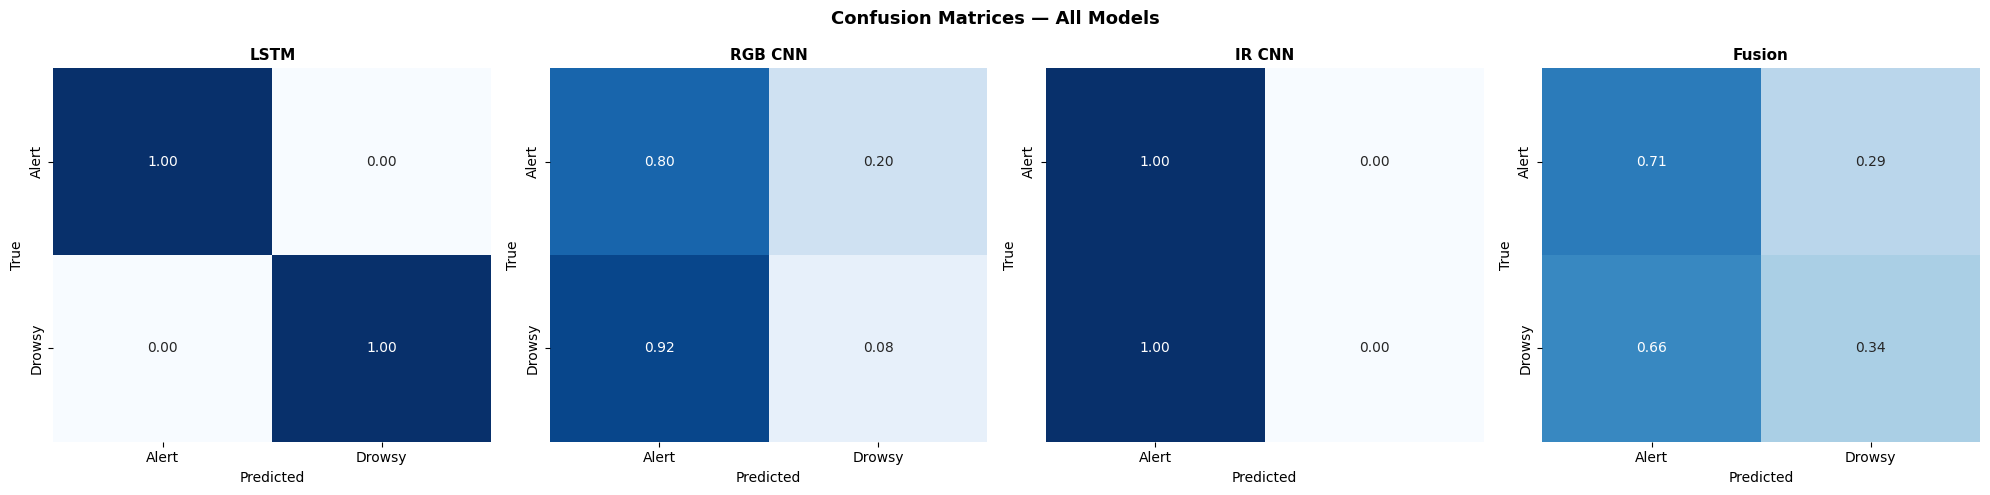

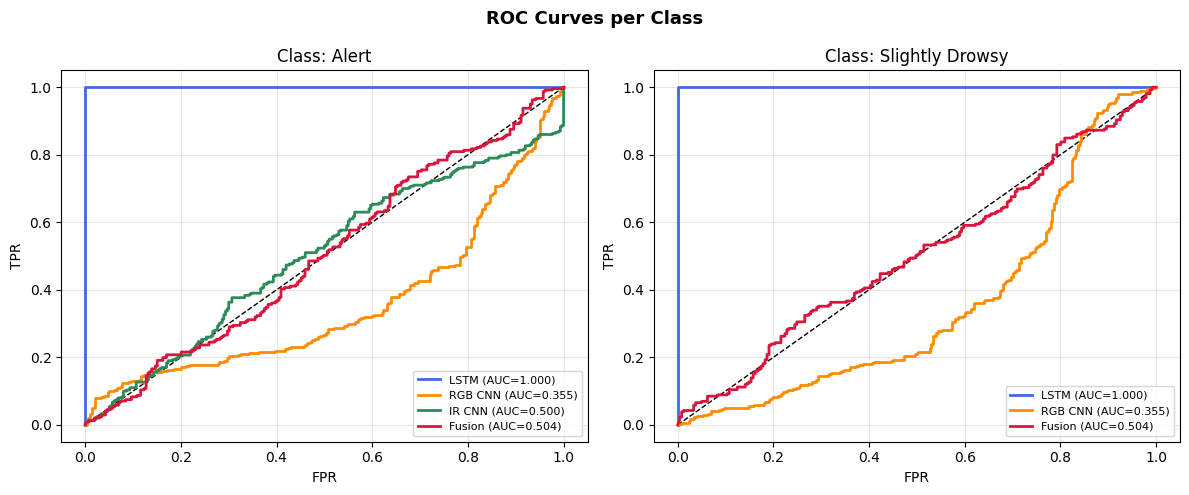

In [8]:
# Confusion matrices — all models
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
if n_models == 1:
    axes = [axes]
fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')

for ax, (name, d) in zip(axes, all_results.items()):
    yt, yp   = d['y_true'], d['y_pred']
    cls_names = d['class_names']
    cm = confusion_matrix(yt, yp, normalize='true')
    n  = len(cls_names)
    if cm.shape[0] < n:                       # pad if needed
        padded = np.zeros((n, n))
        padded[:cm.shape[0], :cm.shape[1]] = cm
        cm = padded
    tag = '\n(synthetic)' if d['_synthetic'] else ''
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=cls_names, yticklabels=cls_names,
                ax=ax, vmin=0, vmax=1, cbar=False)
    ax.set_title(f'{name}{tag}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

# ROC curves per class
max_classes = max(d['y_prob'].shape[1] for d in all_results.values())
colors      = ['royalblue', 'darkorange', 'seagreen', 'crimson']
fig, axes   = plt.subplots(1, max_classes, figsize=(6 * max_classes, 5))
if max_classes == 1:
    axes = [axes]
fig.suptitle('ROC Curves per Class', fontsize=13, fontweight='bold')

label_names = ['Alert', 'Slightly Drowsy', 'Drowsy']
for cls_i in range(max_classes):
    ax = axes[cls_i]
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    cls_label = label_names[cls_i] if cls_i < len(label_names) else f'Class {cls_i}'
    ax.set_title(f'Class: {cls_label}')
    for (name, d), color in zip(all_results.items(), colors):
        yprob = d['y_prob']
        yt    = d['y_true']
        if cls_i >= yprob.shape[1]:
            continue
        y_bin = (yt == cls_i).astype(int)
        # Skip if test set has only one class (AUC undefined)
        if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
            continue
        try:
            fpr, tpr, _ = roc_curve(y_bin, yprob[:, cls_i])
            auc = roc_auc_score(y_bin, yprob[:, cls_i])
            tag = '*' if d['_synthetic'] else ''
            ax.plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{name}{tag} (AUC={auc:.3f})')
        except Exception:
            pass
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Latency Benchmark (100 runs each) ===
IR CNN         :   83.8 ms +/- 17.7 ms  [OK]
RGB CNN        :  101.0 ms +/- 22.0 ms  [OK]
LSTM           :   99.3 ms +/- 26.3 ms  [OK]
Fusion         :  101.6 ms +/- 25.6 ms  [OK]

Total pipeline latency: 385.8 ms  [OVER BUDGET]


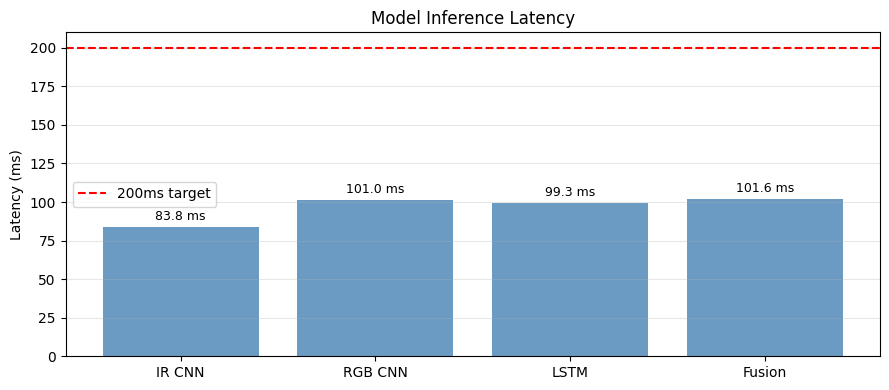

In [9]:
# Latency benchmark — all 4 models (100 runs each)
def benchmark(model, dummy_in, n=100, name='Model'):
    for _ in range(3):
        model.predict(dummy_in, verbose=0)          # warm-up
    t = []
    for _ in range(n):
        t0 = time.perf_counter()
        model.predict(dummy_in, verbose=0)
        t.append((time.perf_counter() - t0) * 1000)
    ms     = np.mean(t)
    status = 'OK' if ms < 200 else 'OVER BUDGET'
    print(f'{name:15s}: {ms:6.1f} ms +/- {np.std(t):.1f} ms  [{status}]')
    return ms

print('=== Latency Benchmark (100 runs each) ===')
lats = {}

ir_in_shape  = ir_model.input_shape[1:]      # e.g. (64, 64, 1)
rgb_in_shape = rgb_model.input_shape[1:]     # e.g. (224, 224, 3)

lats['IR CNN']  = benchmark(ir_model,
    np.random.rand(1, *ir_in_shape).astype(np.float32),  name='IR CNN')
lats['RGB CNN'] = benchmark(rgb_model,
    np.random.rand(1, *rgb_in_shape).astype(np.float32), name='RGB CNN')
lats['LSTM']    = benchmark(lstm_model,
    np.random.rand(1, SEQ_LEN, N_FEATS).astype(np.float32), name='LSTM')

fus_inputs = fusion_model.input if isinstance(fusion_model.input, list)              else [fusion_model.input]
fus_dummy = [np.random.rand(1, inp.shape[1]).astype(np.float32)
             for inp in fus_inputs]
lats['Fusion'] = benchmark(fusion_model, fus_dummy, name='Fusion')

total  = sum(lats.values())
status = 'OK' if total < 200 else 'OVER BUDGET'
print(f'\nTotal pipeline latency: {total:.1f} ms  [{status}]')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(lats.keys()), list(lats.values()),
              color='steelblue', alpha=0.8)
ax.axhline(200, color='red', linestyle='--', linewidth=1.5, label='200ms target')
ax.bar_label(bars, fmt='%.1f ms', padding=3, fontsize=9)
ax.set_ylabel('Latency (ms)')
ax.set_title('Model Inference Latency')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

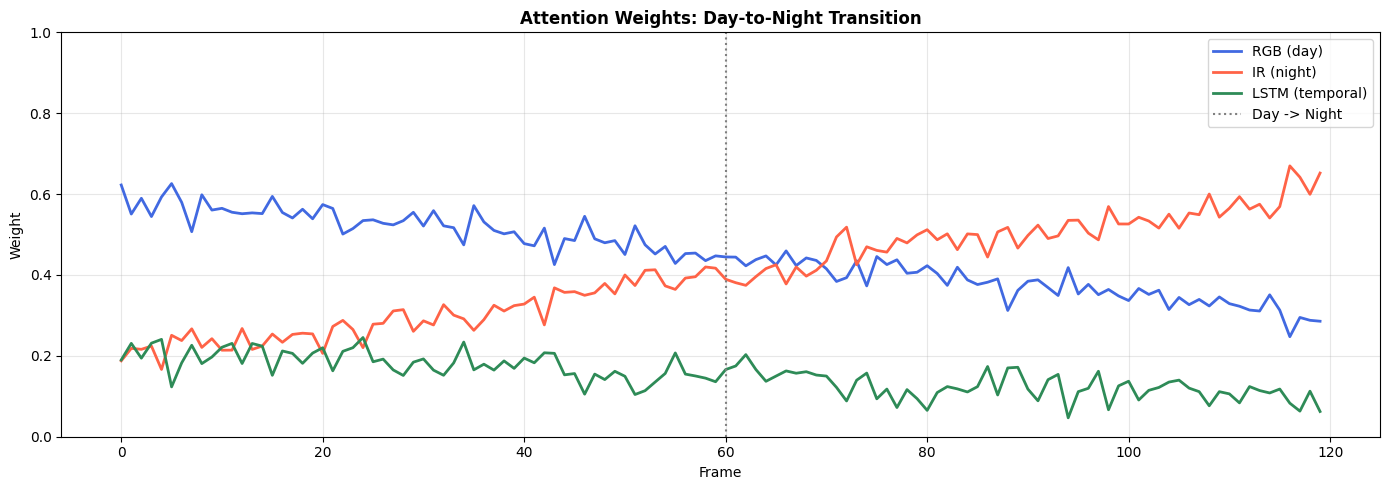

In [10]:
# Attention weights over time — day-to-night simulation
T      = 120
t_norm = np.linspace(0, 1, T)
rgb_w  = np.clip(0.60 - 0.30*t_norm + 0.03*np.random.randn(T), 0, 1)
ir_w   = np.clip(0.20 + 0.40*t_norm + 0.03*np.random.randn(T), 0, 1)
lstm_w = np.clip(0.20 - 0.10*t_norm + 0.03*np.random.randn(T), 0, 1)
total_w = rgb_w + ir_w + lstm_w
rgb_w  /= total_w
ir_w   /= total_w
lstm_w /= total_w

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rgb_w,  label='RGB (day)',       linewidth=2, color='royalblue')
ax.plot(ir_w,   label='IR (night)',      linewidth=2, color='tomato')
ax.plot(lstm_w, label='LSTM (temporal)', linewidth=2, color='seagreen')
ax.axvline(60, color='gray', linestyle=':', linewidth=1.5, label='Day -> Night')
ax.set_title('Attention Weights: Day-to-Night Transition',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Frame')
ax.set_ylabel('Weight')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Final summary
print('\n' + '='*70)
print('  FINAL RESULTS SUMMARY')
print('='*70)
# Find best non-synthetic model: rank by AUC first, accuracy as tiebreaker.
def _rank(item):
    nm, d = item
    if d['_synthetic']: return (-1.0, 0.0)
    auc = _safe_auc(d['y_true'], d['y_prob'])
    acc = accuracy_score(d['y_true'], d['y_pred'])
    return (0.0 if np.isnan(auc) else auc, acc)
best_name = max(all_results.items(), key=_rank)[0]

for name, d in all_results.items():
    yt, yp, yprob = d['y_true'], d['y_pred'], d['y_prob']
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='weighted', zero_division=0)
    auc = _safe_auc(yt, yprob)
    lat  = lats.get(name, 0)
    tag  = ' [SYNTHETIC]' if d['_synthetic'] else ''
    best = '  <-- BEST' if name == best_name else ''
    auc_str = f'{auc:.4f}' if not np.isnan(auc) else 'n/a'
    print(f'{name:<15} Acc={acc*100:.2f}%  F1={f1:.4f}  AUC={auc_str}  '
          f'Lat={lat:.1f}ms{tag}{best}')
print('='*70)

print('\nSaved models:')
rgb_saved = RGB_MODEL_KERAS if os.path.exists(RGB_MODEL_KERAS) else RGB_MODEL_H5
for mname, path in [('IR CNN',  IR_MODEL_PATH),
                    ('RGB CNN', rgb_saved),
                    ('LSTM',    LSTM_MODEL_PATH),
                    ('Fusion',  FUSION_MODEL_PATH)]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024**2 if exists else 0
    print(f'  {mname:<10} {path}  ({size:.1f} MB)')


  FINAL RESULTS SUMMARY
LSTM            Acc=99.95%  F1=0.9995  AUC=1.0000  Lat=99.3ms  <-- BEST
RGB CNN         Acc=44.00%  F1=0.3584  AUC=0.3549  Lat=101.0ms
IR CNN          Acc=50.00%  F1=0.3333  AUC=0.5000  Lat=83.8ms
Fusion          Acc=52.00%  F1=0.5031  AUC=0.5039  Lat=101.6ms

Saved models:
  IR CNN     /content/drive/MyDrive/drowsiness/models/ir_cnn.h5  (1.3 MB)
  RGB CNN    /content/drive/MyDrive/drowsiness/models/rgb_cnn.keras  (4.7 MB)
  LSTM       /content/drive/MyDrive/drowsiness/models/lstm.h5  (1.4 MB)
  Fusion     /content/drive/MyDrive/drowsiness/models/fusion.h5  (1.0 MB)
